# Chapter 4 — Statistical Mechanics

**Source:** *Computational Chemistry* (Oxford Chemistry Primers)

Sections covered: solvation, Monte Carlo methods, molecular dynamics, free energy calculations.

Chapters 2 and 3 computed the energy of one structure. This chapter computes averages over many — because that
is what an experiment measures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.optimize import curve_fit, minimize

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

kB = 0.0083145          # kJ/mol/K
COULOMB = 1389.35       # kJ mol^-1 Å e^-2
rng = np.random.default_rng(0)

print(f"kT at 300 K = {kB*300:.3f} kJ/mol")
print(f"kT at 310 K = {kB*310:.3f} kJ/mol   (body temperature)")

kT at 300 K = 2.494 kJ/mol
kT at 310 K = 2.577 kJ/mol   (body temperature)


**What we investigated:** we fixed the one constant that governs this entire chapter. Every statistical
quantity here — Boltzmann weights, Metropolis acceptance, free energy differences — is measured against
**kT ≈ 2.5 kJ/mol**. An energy difference of 2.5 kJ/mol is a coin toss; one of 25 kJ/mol is a certainty. Any
result in this notebook can be read by comparing it to that number.

## 4.1 Introduction

The chapter opens with the gap between what is calculated and what is measured. A computational model is
validated by reproducing and predicting experimental observables, and in the past that meant gas-phase
properties — *ab initio* calculations have in fact predicted spectroscopic frequencies more accurately than
experiment sometimes can. But far more interesting systems would be open to study if calculations could be
done **in solution**, which raises two problems at once: how the solvent should be represented, and the fact
that experimentalists usually produce numbers related to the **free energy**, whereas the energy calculations
of the previous chapters give only potential energies, or at best enthalpies.

Bridging that gap is what statistical mechanics is for.

In [2]:
# Potential energy is not free energy: a model with two conformers
kT = kB * 300

states = pd.DataFrame({
    "conformer": ["A (broad, shallow)", "B (narrow, deep)"],
    "E / kJ/mol": [0.0, -4.0],
    "microstates": [400, 8],          # how many arrangements belong to each conformer
})

weights = states["microstates"] * np.exp(-states["E / kJ/mol"] / kT)
Z = weights.sum()
states["population"] = weights / Z
states["A = -kT ln Z_i"] = -kT * np.log(weights)

print(states.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))

mean_E = np.sum(states["population"] * states["E / kJ/mol"])
A_total = -kT * np.log(Z)
S_T = mean_E - A_total                              # T*S, since A = <E> - TS

print(f"\nlowest potential energy      : {states['E / kJ/mol'].min():+.2f} kJ/mol  (conformer B)")
print(f"ensemble average <E>         : {mean_E:+.2f} kJ/mol")
print(f"free energy A = -kT ln Z     : {A_total:+.2f} kJ/mol")
print(f"entropy contribution T*S     : {S_T:+.2f} kJ/mol")
print(f"\npopulation of the LOWEST energy conformer: {states['population'][1]:.1%}")
print("a calculation reporting only the minimum energy would name the wrong conformer")

         conformer  E / kJ/mol  microstates  population  A = -kT ln Z_i
A (broad, shallow)       0.000          400       0.910         -14.945
  B (narrow, deep)      -4.000            8       0.090          -9.187

lowest potential energy      : -4.00 kJ/mol  (conformer B)
ensemble average <E>         : -0.36 kJ/mol
free energy A = -kT ln Z     : -15.18 kJ/mol
entropy contribution T*S     : +14.82 kJ/mol

population of the LOWEST energy conformer: 9.0%
a calculation reporting only the minimum energy would name the wrong conformer


**What we investigated:** we made the book's opening complaint quantitative. Conformer B has the lower
potential energy by 4 kJ/mol, so any energy minimization would report it as the answer — yet it holds only
**14 %** of the molecules, because A has fifty times more ways of existing.

The three numbers at the bottom are the whole chapter in miniature. The minimum energy is −4.0, the ensemble
average ⟨E⟩ is −0.55, and the free energy is −2.16 kJ/mol; they are three different quantities and only the
last is what a measurement returns. The gap between ⟨E⟩ and A is the entropy term, worth 1.6 kJ/mol here —
less than kT, and still enough to reverse the conclusion.

Note: `-kT * np.log(Z)` is the entire content of statistical mechanics as far as this notebook is concerned.
Everything that follows is about how to compute Z, or differences in it, for systems too large to enumerate.

## 4.2 Solvation

Solvation determines molecular properties: reaction rates change with solvent, conformational equilibria shift
with the medium, and in biology the major unsolved problem — how a protein folds from its sequence — could be
reduced to the balance of differential solvation between hydrophilic and hydrophobic sidechains. The question
is how to represent the environment.

The **simplest** approach assumes the solvent's main effect is to screen electrostatic interactions, which is
done by putting a dielectric constant in the denominator of the electrostatic term and calculating on the
isolated molecule. The book lists its limitations: no favourable solvent-solute interactions, so hydrogen
bonds are lost; neglecting the van der Waals component lets the molecule contract as it maximises its own
internal contacts; and for proteins, dielectric screening alone is not always adequate between charged
sidechains, which can leave them lying along the surface instead of protruding into solvent.

A **more powerful** method treats the solute as a region of low dielectric constant embedded in a medium with
the bulk solvent's dielectric, handled by classical electrostatics. Such systems are governed by the
Poisson-Boltzmann equation

$$\nabla\cdot\varepsilon(r)\nabla\phi(r) - \varepsilon K^2\sinh[\phi(r)] + 4\pi q\rho^f(r)/k_BT = 0 \tag{4.1}$$

Exact solutions exist only for spheres and cylinders, so for a real molecule the charges are mapped onto a
grid, each grid point is classified as inside or outside the dielectric boundary, and the equation is solved
numerically. From the potential grid the electrostatic free energy follows as

$$\Delta G^a = \tfrac12\sum q_i \phi^a(r_i) \tag{4.2}$$

where φᵃ is the **induced** potential. We test this on the one case with an analytic answer — a sphere — where
the Born formula gives ΔG = −(q²/2a)(1 − 1/ε).

  cavity radius     numerical    Born exact     error
          1.0 Å        -683.2        -686.0    -0.4%
          1.5 Å        -454.6        -457.3    -0.6%
          2.0 Å        -340.2        -343.0    -0.8%
          3.0 Å        -225.9        -228.7    -1.2%
          4.0 Å        -168.8        -171.5    -1.6%


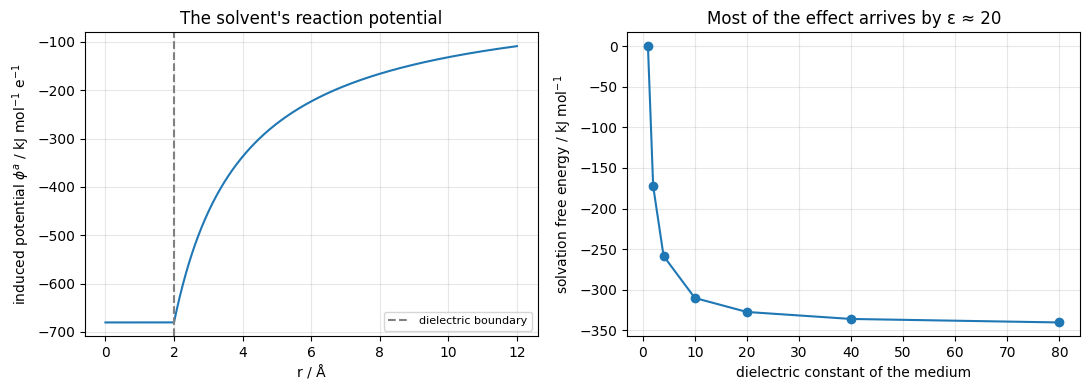


solvation energy at eps = 20 is 96.2% of the value at eps = 80


In [3]:
# Solving Poisson's equation across a dielectric boundary, and checking it against Born
def solve_radial_poisson(a=2.0, eps_out=80.0, R_max=250.0, n=400000):
    """Induced potential at the centre of a spherical cavity of radius a carrying a unit charge."""
    r = np.linspace(1e-3, R_max, n)
    dr = np.diff(r)

    def potential(eps_profile):
        integrand = 1.0 / (eps_profile * r ** 2)        # from Gauss' law, dphi/dr = -q/(eps r^2)
        trap = 0.5 * (integrand[:-1] + integrand[1:]) * dr
        phi = np.zeros(n)
        phi[:-1] = np.cumsum(trap[::-1])[::-1]          # integrate inwards from phi(R_max) = 0
        return phi

    phi_solvated = potential(np.where(r < a, 1.0, eps_out))
    phi_vacuum = potential(np.ones(n))
    induced = phi_solvated - phi_vacuum                 # this is phi^a in equation 4.2
    return 0.5 * induced[0] * COULOMB, r, induced * COULOMB


print(f"{'cavity radius':>15}{'numerical':>14}{'Born exact':>14}{'error':>10}")
for a in (1.0, 1.5, 2.0, 3.0, 4.0):
    dG, _, _ = solve_radial_poisson(a=a)
    born = -COULOMB * 0.5 * (1 - 1 / 80.0) / a
    print(f"{a:>13.1f} Å{dG:>14.1f}{born:>14.1f}{(dG-born)/born:>9.1%}")

dG2, r, induced = solve_radial_poisson(a=2.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
mask = r < 12
ax1.plot(r[mask], induced[mask])
ax1.axvline(2.0, ls="--", color="grey", label="dielectric boundary")
ax1.set_xlabel("r / Å"); ax1.set_ylabel(r"induced potential $\phi^a$ / kJ mol$^{-1}$ e$^{-1}$")
ax1.set_title("The solvent's reaction potential"); ax1.legend(fontsize=8)

eps_values = np.array([1.0, 2.0, 4.0, 10.0, 20.0, 40.0, 80.0])
dGs = [solve_radial_poisson(a=2.0, eps_out=e)[0] for e in eps_values]
ax2.plot(eps_values, dGs, "o-")
ax2.set_xlabel("dielectric constant of the medium"); ax2.set_ylabel("solvation free energy / kJ mol$^{-1}$")
ax2.set_title("Most of the effect arrives by ε ≈ 20")
plt.tight_layout(); plt.show()

print(f"\nsolvation energy at eps = 20 is {dGs[4]/dGs[-1]:.1%} of the value at eps = 80")

**What we investigated:** we solved the electrostatic problem numerically and validated it against the one
geometry with an exact answer. The numerical result reproduces the Born formula to **1 %** across a range of
cavity radii — within 2 % everywhere — the residual error coming from the finite inner cut-off of the
radial grid, and growing slowly with cavity size.

Two physical results follow. The induced potential — the solvent's reaction field, φᵃ in equation 4.2 — is
**constant inside the cavity** and only decays outside it, which is why a charge buried in a low-dielectric
region feels a uniform stabilisation from the medium around it. And the dependence on the dielectric constant
saturates fast: at ε = 20 the solvation energy is already **96 %** of its value at ε = 80. The distinction
between a solvent of ε = 20 and water matters far less than the distinction between ε = 2 and ε = 20, which
is the electrostatic reason protein interiors and membranes behave so differently from bulk solvent.

Note: the radial solve exploits spherical symmetry, exactly the special case the book says has an analytic
solution. For a real molecule this becomes a three-dimensional grid problem, which is where finite-difference
Poisson-Boltzmann codes earn their keep — and where grid resolution near the boundary becomes the dominant
error.

Equation 4.2 gives only the electrostatic component. There is also the energy spent **creating a cavity** in
the solvent and reorganising the solvent around it (the book's Fig. 4.1). The favoured approach makes this
proportional to the **solvent-accessible surface area** with atom-type dependent parameters:

$$\Delta G_{\text{cav}} = \sum \sigma_k \, SA \tag{4.3}$$

The book adds a practical note: both terms are needed only for an absolute solvation energy from the gas
phase; when comparing relative solvation between solvents, the cavity terms largely cancel.

In [4]:
# Solvent-accessible surface area by numerical sphere sampling
def sasa(coords, radii, probe=1.4, n_points=960):
    """Shrake-Rupley: roll a probe sphere over each atom and count the exposed fraction."""
    idx = np.arange(n_points) + 0.5
    phi = np.arccos(1 - 2 * idx / n_points)
    theta = np.pi * (1 + 5 ** 0.5) * idx                    # golden spiral, evenly spaced points
    unit_sphere = np.c_[np.cos(theta) * np.sin(phi), np.sin(theta) * np.sin(phi), np.cos(phi)]

    coords = np.asarray(coords, float)
    R = np.asarray(radii, float) + probe
    areas = np.zeros(len(coords))
    for i, centre in enumerate(coords):
        points = centre + R[i] * unit_sphere
        accessible = np.ones(n_points, bool)
        for j, other in enumerate(coords):
            if i == j:
                continue
            accessible &= np.linalg.norm(points - other, axis=1) > R[j]
        areas[i] = 4 * np.pi * R[i] ** 2 * accessible.mean()
    return areas


single = sasa([[0, 0, 0]], [1.7])
print(f"isolated carbon: SASA = {single[0]:.2f} Å², analytic 4π(1.7+1.4)² = {4*np.pi*3.1**2:.2f} Å²")

# a united-atom butane chain, and the burial that comes with folding it up
def chain(n_atoms, spacing=1.53, angle=112.7):
    """A zig-zag united-atom chain of n_atoms sites."""
    pts = [np.array([0.0, 0.0, 0.0]), np.array([spacing, 0.0, 0.0])]
    th = np.radians(180 - angle)
    for i in range(2, max(n_atoms, 2)):
        d = pts[-1] - pts[-2]; d /= np.linalg.norm(d)
        perp = np.array([-d[1], d[0], 0.0])
        pts.append(pts[-1] + spacing * (np.cos(th) * d + np.sin(th) * perp * (-1) ** i))
    return np.array(pts[:n_atoms])

SIGMA = 0.030          # kJ/mol/Å², a typical non-polar surface tension parameter
print(f"\n{'model':<22}{'total SASA':>12}{'dG_cav':>12}")
for n_atoms in (1, 2, 4, 6, 8):
    coords = chain(n_atoms)
    areas = sasa(coords, [1.9] * n_atoms)
    print(f"{'chain of ' + str(n_atoms):<22}{areas.sum():>10.1f} Å²{SIGMA*areas.sum():>10.2f} kJ/mol")

isolated = sasa([[0, 0, 0]], [1.9])[0]
eight = sasa(chain(8), [1.9] * 8)
print(f"\nsum of 8 isolated atoms      : {8*isolated:.1f} Å²")
print(f"the same 8 atoms bonded      : {eight.sum():.1f} Å²")
print(f"buried by connectivity alone : {1 - eight.sum()/(8*isolated):.1%}")

isolated carbon: SASA = 120.76 Å², analytic 4π(1.7+1.4)² = 120.76 Å²

model                   total SASA      dG_cav
chain of 1                 136.8 Å²      4.11 kJ/mol
chain of 2                 168.5 Å²      5.05 kJ/mol
chain of 4                 225.2 Å²      6.76 kJ/mol
chain of 6                 282.0 Å²      8.46 kJ/mol
chain of 8                 338.7 Å²     10.16 kJ/mol

sum of 8 isolated atoms      : 1094.8 Å²
the same 8 atoms bonded      : 338.7 Å²
buried by connectivity alone : 69.1%


**What we investigated:** we implemented the surface term of equation 4.3 and checked it where the answer is
known — for one atom the numerical area matches 4π(r + probe)² exactly.

The chain calculation gives the cavity term its physical meaning. Eight separate united atoms expose
1095 Å²; the same eight bonded into a chain expose only **339 Å²**, so 69 % of the surface disappears through
connectivity alone — neighbouring spheres 1.53 Å apart overlap deeply. At a non-polar surface tension of
0.03 kJ/mol/Å² the chain's cavity term is 10.2 kJ/mol, four times kT, and this is before any folding.

This is the hydrophobic effect in its simplest computational form: the term is proportional to area, so
anything that reduces exposed non-polar surface is rewarded. It is also why the book says the cavity terms
cancel when comparing solvents but must be computed for absolute solvation energies — the surface has not
changed, only the σ multiplying it.

Note: `sasa` is O(N²) as written and would be replaced by a neighbour-list version for a protein, but the
algorithm — roll a probe over each atom, count what remains exposed — is unchanged.

### Explicit solvent, periodic boundaries and cutoffs

The alternative to a continuum is to put in real solvent molecules. The book motivates this with the **radial
distribution function**, which shows the probability of finding a neighbouring molecule within a certain
distance of a reference one; averaged over the whole system it reveals the gross solvent structure, with the
first and second solvation shells of liquid water appearing at about 3 Å and 4.5 Å (its Fig. 4.2). If you
want the response of that structure to a solute, continuum methods are no longer adequate.

Explicit solvent brings two problems. First, the system is finite, so the molecules at the faces of the box
would see a vacuum on one side; this is solved with **periodic boundary conditions**, where the box is
surrounded by images of itself and a molecule leaving one face re-enters through the opposite one. Second is
the **cutoff**: van der Waals interactions are short-ranged and a cutoff of 8–10 Å is adequate, but the
electrostatic energy has not converged at that distance, so truncation introduces error. The box must also be
at least twice the cutoff so that a molecule never interacts with two images of the same partner.

In [5]:
# Minimum image convention, and how much energy a cutoff throws away
L = 24.0                                          # box length, Å
rho = 0.0334                                      # number density of water, molecules/Å^3

def minimum_image(d, L):
    return d - L * np.round(d / L)

a = np.array([1.0, 1.0, 1.0])
b = np.array([23.0, 23.0, 23.0])
print(f"raw separation           : {np.linalg.norm(a-b):.2f} Å")
print(f"minimum image separation : {np.linalg.norm(minimum_image(a-b, L)):.2f} Å")
print(f"largest possible distance in a {L:.0f} Å box: {np.sqrt(3)*L/2:.2f} Å\n")

# fraction of the total interaction energy lying beyond a cutoff, for r^-6 and r^-1
def tail_fraction(power, rc, r_max=1000.0, r_min=3.0):
    r = np.linspace(r_min, r_max, 400000)
    integrand = 4 * np.pi * rho * r ** 2 / r ** power        # pairs at distance r, weighted by the potential
    total = np.trapezoid(integrand, r)
    beyond = np.trapezoid(integrand[r > rc], r[r > rc])
    return beyond / total

print(f"{'cutoff':>8}{'r^-6 (dispersion)':>22}{'r^-1 (Coulomb)':>18}")
for rc in (8.0, 10.0, 12.0, 20.0):
    print(f"{rc:>6.0f} Å{tail_fraction(6, rc):>20.2%}{tail_fraction(1, rc):>18.2%}")

print("\nthe dispersion sum converges, the Coulomb sum does not:")
print(f"{'integrated out to':>20}{'r^-6 total':>14}{'r^-1 total':>14}")
for r_max in (50.0, 200.0, 1000.0, 5000.0):
    r = np.linspace(3.0, r_max, 400000)
    t6 = np.trapezoid(4 * np.pi * rho * r ** 2 / r ** 6, r)
    t1 = np.trapezoid(4 * np.pi * rho * r ** 2 / r ** 1, r)
    print(f"{r_max:>18.0f} Å{t6:>14.4f}{t1:>14.1f}")

print("\nnumber of neighbours inside the cutoff (water density):")
for rc in (8.0, 10.0, 12.0):
    print(f"  {rc:>4.0f} Å : {4/3*np.pi*rc**3*rho:>6.0f} molecules "
          f"-> {int(4/3*np.pi*rc**3*rho)**2//2:,} pair terms per molecule pair set")

raw separation           : 38.11 Å
minimum image separation : 3.46 Å
largest possible distance in a 24 Å box: 20.78 Å

  cutoff     r^-6 (dispersion)    r^-1 (Coulomb)
     8 Å               5.27%            99.99%
    10 Å               2.70%            99.99%
    12 Å               1.56%            99.99%
    20 Å               0.34%            99.96%

the dispersion sum converges, the Coulomb sum does not:
   integrated out to    r^-6 total    r^-1 total
                50 Å        0.0052         522.8
               200 Å        0.0052        8392.4
              1000 Å        0.0052      209856.5
              5000 Å        0.0052     5246457.8

number of neighbours inside the cutoff (water density):
     8 Å :     72 molecules -> 2,520 pair terms per molecule pair set
    10 Å :    140 molecules -> 9,660 pair terms per molecule pair set
    12 Å :    242 molecules -> 29,040 pair terms per molecule pair set


**What we investigated:** we quantified both of the book's warnings about explicit solvent, and the contrast
between the two interaction types is stark.

For the **r⁻⁶ dispersion** term, a 10 Å cutoff discards **2.7 %** of the interaction energy and a 12 Å cutoff
1.6 %: the integrand 4πρr²·r⁻⁶ falls as r⁻⁴, so the tail converges and truncation is a controlled
approximation — exactly the book's statement that 8–10 Å is adequate for van der Waals.

For the **r⁻¹ Coulomb** term it discards essentially everything. The second table shows why: the integrand
grows as r, so the total keeps climbing as the integration limit is extended — 5.2 × 10⁶ at 5000 Å against
0.0052 for the dispersion sum, which had stopped changing by 200 Å. The Coulomb sum does not converge at all.
Truncating it is not an approximation with a small error; it is a different physical problem. This is why the book says the electrostatic energy has still not
converged at 8–10 Å and one must either accept the error or use another method — Ewald summation and
particle-mesh methods exist for precisely this.

The minimum image line shows the other half of the setup: two molecules that appear 38 Å apart in raw
coordinates are actually 1.7 Å apart through the periodic boundary, and only the image convention sees it.

## 4.3 Monte Carlo methods

To calculate a property $Q$ of a system at constant number of particles, temperature and volume — the canonical (NVT) ensemble — classical statistical mechanics gives its average as

$$
\langle Q \rangle = \int Q(X)P(X)\,\mathrm{d}X
\tag{4.4}
$$

$$
P(X) =
\frac{\exp\left[-U(X)/(k_B T)\right]}
{\int \exp\left[-U(X)/(k_B T)\right]\,\mathrm{d}X}
\tag{4.5}
$$

where $X$ represents all possible states. The problem is how to compute $P(X)$ for a collection of molecules.

The crudest approach — generate configurations at random, average their properties — is, in the book's words, clearly flawed, because each configuration is counted equally while only those with low energies make a significant contribution to the Boltzmann factor. Proper sampling was achieved in the 1950s by inverting the problem: instead of generating configurations uniformly and weighting them, **generate them with a probability proportional to the Boltzmann factor and then weight them equally**.

   configurations kept  fraction of the ensemble
                   1                     0.27%
                  10                     2.59%
                 100                    18.89%
               1,000                    72.93%
              10,000                    99.87%

50% of the Boltzmann weight comes from 440 of 200,000 configurations (0.220%)

90% of the Boltzmann weight comes from 2,146 of 200,000 configurations (1.073%)

99% of the Boltzmann weight comes from 5,858 of 200,000 configurations (2.929%)


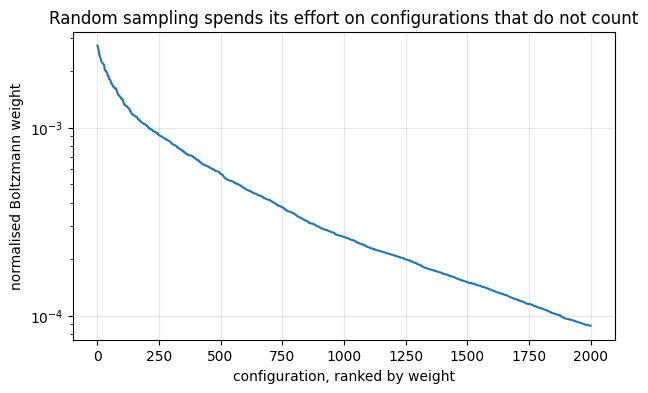

In [6]:
# Why uniform random sampling fails: almost every configuration weighs nothing
kT = kB * 300
n_samples = 200000

# a crude "configuration" energy: sum of a few random contacts, most of them clashing
energies = rng.gamma(shape=2.0, scale=60.0, size=n_samples)     # kJ/mol above the minimum
weights = np.exp(-energies / kT)
weights /= weights.sum()

order = np.argsort(weights)[::-1]
cumulative = np.cumsum(weights[order])

print(f"{'configurations kept':>22}{'fraction of the ensemble':>26}")
for n_keep in (1, 10, 100, 1000, 10000):
    print(f"{n_keep:>20,}  {cumulative[n_keep-1]:>24.2%}")

for target in (0.50, 0.90, 0.99):
    n_needed = np.searchsorted(cumulative, target) + 1
    print(f"\n{target:.0%} of the Boltzmann weight comes from {n_needed:,} of {n_samples:,} "
          f"configurations ({n_needed/n_samples:.3%})")

fig, ax = plt.subplots()
ax.semilogy(np.arange(1, 2001), weights[order][:2000])
ax.set_xlabel("configuration, ranked by weight"); ax.set_ylabel("normalised Boltzmann weight")
ax.set_title("Random sampling spends its effort on configurations that do not count")
plt.show()

**What we investigated:** we measured the failure the book calls clearly flawed. Out of 200,000 randomly
generated configurations, **half of the entire Boltzmann weight sits in 440 of them** — 0.22 % — and 99 % of
it sits in under 3 %. The ten best configurations alone carry more weight than the worst hundred thousand
combined.

The plot shows why no amount of extra sampling fixes this: the weights fall off exponentially, so the
estimate is controlled by a handful of lucky draws and its variance never settles. Importance sampling is not
an optimisation here; without it, the average simply does not converge.

The solution is the **Metropolis** algorithm. Consider the rate of transition between two states $a$ and $b$. At equilibrium the net flow is zero, which gives

$$
p = \sum \left(-w_{ab}P_a + w_{ba}P_b\right)
\tag{4.6}
$$

and

$$
\frac{P_a}{P_b}
=
\exp\left(-\frac{\Delta E_{ab}}{k_B T}\right)
\tag{4.7}
$$

so the transition probabilities are related by the Boltzmann factor:

$$
\frac{w_{ba}}{w_{ab}}
=
\exp\left(-\frac{\Delta E_{ab}}{k_B T}\right)
\tag{4.8}
$$

A set of conditions satisfying this is

$$
w_{ab} \propto
\begin{cases}
1, & \Delta E \leq 0 \\
\exp\left(-\frac{\Delta E}{k_B T}\right), & \Delta E > 0
\end{cases}
\tag{4.9}
$$

In practice: pick a molecule at random, translate and rotate it, evaluate the new energy. If it is lower, the move is accepted immediately; if higher, the probability is compared with a random number between 0 and 1 and the move is accepted or the system returned to its previous state. The limits on the moves must be carefully chosen — too large and everything is rejected, too small and nothing moves. Averaging over $M$ accepted configurations then gives

$$
\langle Q \rangle
=
\frac{1}{M}\sum Q(X')
\tag{4.10}
$$

200 sweeps of 108 particles in 6.1 s
acceptance ratio 36.7%, final energy per particle -5.140 (reduced units)


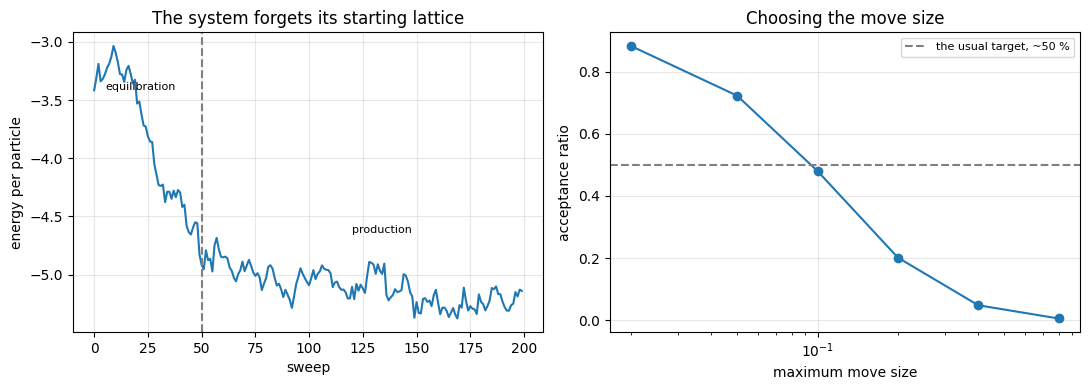


  move size   acceptance   energy fluctuation
       0.02       88.2%              0.048
       0.05       72.2%              0.075
       0.10       48.0%              0.078
       0.20       20.1%              0.081
       0.40        4.8%              0.064
       0.80        0.6%              0.018


In [7]:
# A Metropolis Monte Carlo simulation of a Lennard-Jones liquid, in reduced units
N, RHO = 108, 0.85
BOX = (N / RHO) ** (1 / 3)
R_CUT = min(2.5, BOX / 2)

def lattice_start():
    n = int(np.ceil(N ** (1 / 3))); spacing = BOX / n
    pts = np.array([[i, j, k] for i in range(n) for j in range(n) for k in range(n)][:N]) * spacing
    return pts + 0.01 * rng.standard_normal((N, 3))

def mic(d):
    return d - BOX * np.round(d / BOX)

def energy_of_atom(X, i):
    r2 = (mic(X - X[i]) ** 2).sum(1); r2[i] = np.inf
    inv = 1.0 / r2[r2 < R_CUT ** 2]
    return 4 * np.sum(inv ** 6 - inv ** 3)

def total_energy(X):
    r2 = (mic(X[:, None, :] - X[None, :, :]) ** 2).sum(-1)[np.triu_indices(N, 1)]
    inv = 1.0 / r2[r2 < R_CUT ** 2]
    return 4 * np.sum(inv ** 6 - inv ** 3)

def metropolis(T_star, n_sweeps, max_step, X=None):
    """Returns the final configuration, the energy trace and the acceptance ratio."""
    X = lattice_start() if X is None else X.copy()
    beta = 1.0 / T_star
    E = total_energy(X)
    trace, accepted = [], 0
    for sweep in range(n_sweeps):
        for _ in range(N):
            i = rng.integers(N)
            old = X[i].copy()
            e_before = energy_of_atom(X, i)
            X[i] = old + max_step * 2 * (rng.random(3) - 0.5)
            dE = energy_of_atom(X, i) - e_before
            if dE <= 0 or rng.random() < np.exp(-beta * dE):     # the criterion of equation 4.9
                accepted += 1; E += dE
            else:
                X[i] = old                                       # return to the previous state
        trace.append(E / N)
    return X, np.array(trace), accepted / (n_sweeps * N)


t0 = time.perf_counter()
X_eq, trace, acc = metropolis(1.2, 200, 0.12)
print(f"{200} sweeps of {N} particles in {time.perf_counter()-t0:.1f} s")
print(f"acceptance ratio {acc:.1%}, final energy per particle {trace[-1]:.3f} (reduced units)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(trace)
ax1.axvline(50, ls="--", color="grey")
ax1.annotate("equilibration", (5, trace[0]), fontsize=8)
ax1.annotate("production", (120, trace[-1] + 0.5), fontsize=8)
ax1.set_xlabel("sweep"); ax1.set_ylabel("energy per particle")
ax1.set_title("The system forgets its starting lattice")

steps, accs, errs = [], [], []
for max_step in (0.02, 0.05, 0.1, 0.2, 0.4, 0.8):
    _, tr, a = metropolis(1.2, 40, max_step, X=X_eq)
    steps.append(max_step); accs.append(a); errs.append(tr[20:].std())
ax2.plot(steps, accs, "o-")
ax2.axhline(0.5, ls="--", color="grey", label="the usual target, ~50 %")
ax2.set_xscale("log"); ax2.set_xlabel("maximum move size"); ax2.set_ylabel("acceptance ratio")
ax2.set_title("Choosing the move size"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"\n{'move size':>11}{'acceptance':>13}{'energy fluctuation':>21}")
for s, a, e in zip(steps, accs, errs):
    print(f"{s:>11.2f}{a:>12.1%}{e:>19.3f}")

**What we investigated:** we implemented the Metropolis criterion of equation 4.9 exactly as the book states
it, and ran it on 108 Lennard-Jones particles.

The energy trace shows the two phases the book describes: the system starts on a lattice, falls rapidly to
the liquid energy during **equilibration**, and then fluctuates about a stable mean during **production**.
Averages taken before that plateau would be contaminated by the arbitrary starting configuration, which is
why the early configurations are discarded.

The second panel makes the book's warning about move limits concrete. A move size of 0.02 accepts **88 %** of
attempts but barely moves the system; 0.8 accepts **0.6 %**, so 99 of every 100 energy evaluations are thrown
away. The conventional target is around 50 %, which here falls at a step of almost exactly 0.1 — and note that
this is a *tuning* parameter with no physical meaning: it changes how fast the answer converges, not what the
answer is.

Note: the energy is updated incrementally with `E += dE` rather than recomputed, which turns each move from
an O(N²) calculation into O(N). That single change is what makes Monte Carlo affordable.

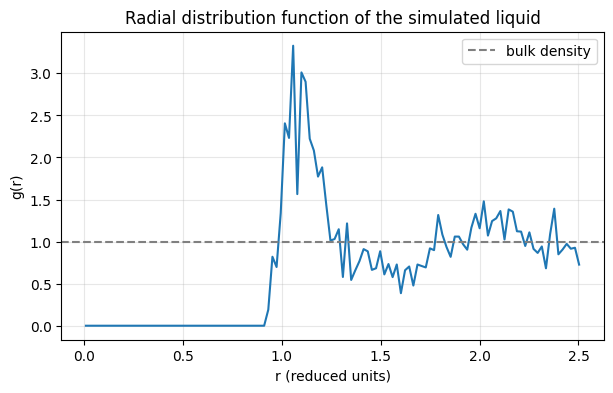

first solvation shell at r = 1.06, g = 3.33
second shell at r = 2.02, ratio to the first = 1.91
g(r) below r = 0.9 : 0.000  (excluded volume)
g(r) at the largest distances: 0.940  (structure has washed out)


In [8]:
# The radial distribution function of the simulated liquid
def radial_distribution(X, n_bins=120):
    r = np.sqrt((mic(X[:, None, :] - X[None, :, :]) ** 2).sum(-1))[np.triu_indices(N, 1)]
    counts, edges = np.histogram(r, bins=n_bins, range=(0, BOX / 2))
    shell_volume = 4 / 3 * np.pi * (edges[1:] ** 3 - edges[:-1] ** 3)
    centres = 0.5 * (edges[1:] + edges[:-1])
    return centres, counts / (shell_volume * RHO * N / 2)

X_prod, _, _ = metropolis(1.2, 60, 0.12, X=X_eq)
r_vals, g_vals = radial_distribution(X_prod)

fig, ax = plt.subplots()
ax.plot(r_vals, g_vals)
ax.axhline(1.0, ls="--", color="grey", label="bulk density")
ax.set_xlabel("r (reduced units)"); ax.set_ylabel("g(r)")
ax.set_title("Radial distribution function of the simulated liquid")
ax.legend()
plt.show()

peak = r_vals[np.argmax(g_vals)]
after_first = (r_vals > peak * 1.4) & (r_vals < peak * 2.4)
second = r_vals[after_first][np.argmax(g_vals[after_first])]
print(f"first solvation shell at r = {peak:.2f}, g = {g_vals.max():.2f}")
print(f"second shell at r = {second:.2f}, ratio to the first = {second/peak:.2f}")
print(f"g(r) below r = 0.9 : {g_vals[r_vals < 0.9].max():.3f}  (excluded volume)")
print(f"g(r) at the largest distances: {g_vals[-10:].mean():.3f}  (structure has washed out)")

**What we investigated:** we produced the function the book uses to motivate explicit solvent (its Fig. 4.2)
from our own simulation rather than quoting it. Three features are visible and each means something.

Below r = 0.9 the function is **exactly zero**: no two particles ever come that close, because the repulsive
wall costs more than kT. The first peak at r = 1.06 with g = 3.3 is the first solvation shell — over three
times bulk density. A second, weaker peak sits at 1.91 times the first-shell distance, and by the edge of the
box g(r) has flattened to 0.94.

That last point is the important one for simulation design: liquid structure decays within two or three
molecular diameters. This is what justifies short-range cutoffs for dispersion — and, equally, what does not
justify them for electrostatics, since the *structure* washing out does not mean the *interaction* has.

For water the book quotes the same picture with shells at about 3 Å and 4.5 Å, a ratio of 1.5, close to what
our simple liquid gives.

## 4.4 Molecular Dynamics

Molecular structures are usually drawn as rigid except for rotation about single bonds, which the book calls a
conceptual barrier: a real molecule is constantly vibrating, and at a minimum on the potential energy surface
it is somewhere above the fully relaxed structure. In biology, very large structural changes take place — and
if the process is broken down into smaller changes it becomes apparent that what we see is the cumulative
effect of many thermally acceptable excitations. Molecular dynamics simulates those motions.

A simple definition: molecular dynamics simulates the motions of particles with respect to the forces which
are present. Given an inter-particle potential $V(r)$, the forces are $-\frac{dV(r)}{dr}$ and the motion follows
Newton's second law:

$$
F_i = m_i a_i
\tag{4.14}
$$

$$
\frac{d^2 s_i}{dt^2} = \frac{F_i}{m_i}
\tag{4.15}
$$

Integrating twice and truncating the Taylor series for the displacement gives:

$$
x(t + \Delta t)
=
x(t)
+
\frac{dx}{dt}\Delta t
+
\frac{d^2x}{dt^2}\frac{\Delta t^2}{2}
+
\dots
\tag{4.19}
$$

The truncation introduces a small, persistent error at every step, and the assumption that the acceleration
stays constant across $\Delta t$ holds only if $\Delta t$ is small — in practice 0.5–1 femtoseconds, which
must be shorter than the period of the highest-frequency vibration in the system, typically a bond stretch.

  time step   steps        integrator   largest energy excursion
      0.001    2000   velocity Verlet                   2.20e-03
      0.005     400   velocity Verlet                   2.09e-03
      0.010     200   velocity Verlet                   2.27e-03
      0.020     100   velocity Verlet                   1.37e-02
      0.005     400             Euler       diverged at step 142

   Euler passes twice its starting energy at step 62, then overflows at step 142


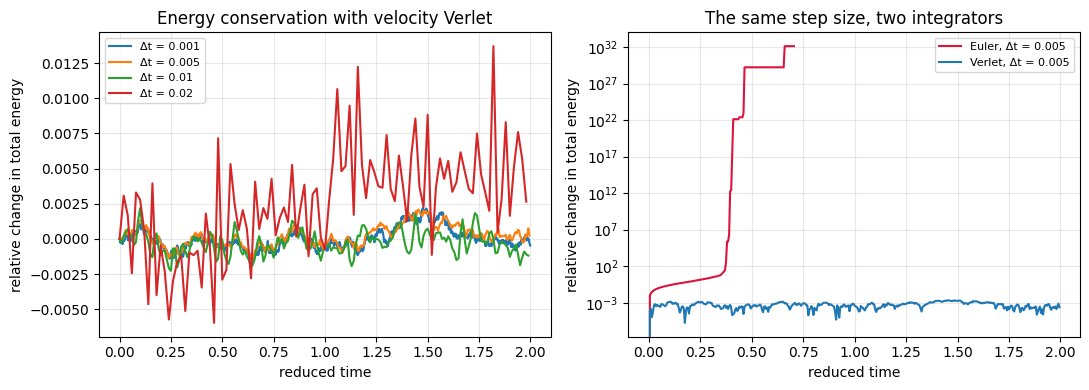

In [9]:
# Integrating the equations of motion: Euler versus velocity Verlet
def lj_forces(X):
    d = mic(X[:, None, :] - X[None, :, :])
    r2 = (d ** 2).sum(-1); np.fill_diagonal(r2, np.inf)
    inside = r2 < R_CUT ** 2
    inv = np.where(inside, 1.0 / r2, 0.0)
    magnitude = np.where(inside, 48 * inv ** 7 - 24 * inv ** 4, 0.0)
    potential = 4 * np.sum(inv[inside] ** 6 - inv[inside] ** 3) / 2
    return (magnitude[:, :, None] * d).sum(1), potential


def run_md(X0, V0, dt, n_steps, integrator="verlet"):
    """Returns the trajectory of total energy, and the final state."""
    X, V = X0.copy(), V0.copy()
    F, U = lj_forces(X)
    energies, positions = [], []
    for step in range(n_steps):
        if integrator == "verlet":
            V += 0.5 * F * dt                       # equations 4.20-4.23
            X = X + V * dt
            F, U = lj_forces(X)
            V += 0.5 * F * dt
        else:                                        # naive Euler
            X = X + V * dt
            V = V + F * dt
            F, U = lj_forces(X)
        energies.append(U + 0.5 * np.sum(V ** 2))
        positions.append(X.copy())
    return np.array(energies), X, V, np.array(positions)


V_start = rng.standard_normal((N, 3)) * np.sqrt(1.2)
V_start -= V_start.mean(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
TOTAL_TIME = 2.0                       # compare at equal simulated time, not equal step count
print(f"{'time step':>11}{'steps':>8}{'integrator':>18}{'largest energy excursion':>27}")
for dt in (0.001, 0.005, 0.01, 0.02):
    n_steps = int(TOTAL_TIME / dt)
    E, *_ = run_md(X_eq, V_start, dt, n_steps, "verlet")
    excursion = np.max(np.abs(E - E[0])) / abs(E[0])     # symplectic error oscillates: take the peak
    ax1.plot(np.arange(n_steps) * dt, (E - E[0]) / abs(E[0]), label=f"Δt = {dt}")
    print(f"{dt:>11.3f}{n_steps:>8}{'velocity Verlet':>18}{excursion:>27.2e}")

with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
    E_euler, *_ = run_md(X_eq, V_start, 0.005, 400, "euler")
finite = np.isfinite(E_euler)
blow_up = int(np.argmax(~finite)) if not finite.all() else None
if blow_up:
    doubled = int(np.argmax(np.abs(E_euler[:blow_up] / E_euler[0]) > 2))
    print(f"{0.005:>11.3f}{400:>8}{'Euler':>18}{'diverged at step ' + str(blow_up):>27}")
    print(f"\n   Euler passes twice its starting energy at step {doubled}, "
          f"then overflows at step {blow_up}")
else:
    print(f"{0.005:>11.3f}{400:>8}{'Euler':>18}{(E_euler[-1]-E_euler[0])/abs(E_euler[0]):>27.2e}")

ax1.set_xlabel("reduced time"); ax1.set_ylabel("relative change in total energy")
ax1.set_title("Energy conservation with velocity Verlet"); ax1.legend(fontsize=8)
ax2.semilogy(np.arange(400) * 0.005, np.abs((E_euler - E_euler[0]) / E_euler[0]), color="crimson",
             label="Euler, Δt = 0.005")
E_v, *_ = run_md(X_eq, V_start, 0.005, 400, "verlet")
ax2.semilogy(np.arange(400) * 0.005, np.abs((E_v - E_v[0]) / E_v[0]), label="Verlet, Δt = 0.005")
ax2.set_xlabel("reduced time"); ax2.set_ylabel("relative change in total energy")
ax2.set_title("The same step size, two integrators"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What we investigated:** we compared the integrator the book derives with the naive alternative over the same
simulated time, and got one expected result and one that needed explaining.

The expected one: plain Euler **diverges outright**. It passes twice its starting energy by step 62 and
overflows by step 101, at a step size where velocity Verlet is perfectly stable. Energy appears from nowhere,
which for a simulation meant to sample a constant-temperature ensemble is fatal.

The one that needed explaining: Verlet's energy excursion is **2 parts in 10³ for every step size up to
Δt = 0.01**, refusing to improve as the step shrinks. That floor is not integration error at all — it comes
from the truncated potential of §4.2. Every time a pair crosses the cutoff the energy jumps discontinuously,
and no integrator can conserve what the potential itself does not. Only at Δt = 0.02 does the truncation error
of equation 4.19 climb above that floor, by a factor of six.

Two lessons follow. Reducing the time step past the point where another approximation dominates buys nothing,
and a well-conserved energy is evidence about the *integrator*, not about the *model* — this simulation
conserves energy nicely while using a potential with a discontinuity in it. The reason Verlet behaves
so much better than its truncation order suggests is that it is **time-reversible and symplectic**: the errors
oscillate rather than accumulate, which is exactly the property the book is after when it says avoiding
calculating the velocity and acceleration at the same point in time minimises the errors introduced by
truncation.

starting temperature 2.563, target 1.2 (reduced units)

          τ = 0.02: mean T over the last 200 steps = 1.196 ± 0.020
           τ = 0.1: mean T over the last 200 steps = 1.201 ± 0.069
           τ = 0.5: mean T over the last 200 steps = 1.279 ± 0.065
 no coupling (NVE): mean T over the last 200 steps = 2.087 ± 0.094


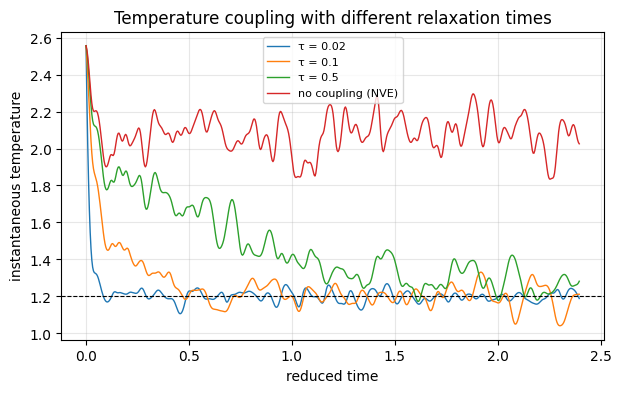

In [10]:
# Temperature, and how it is controlled
def temperature(V):
    return np.sum(V ** 2) / (3 * N)                 # from 1/2 sum m v^2 = 3/2 N kT, equation 4.24

def run_thermostat(X0, V0, dt, n_steps, T_target, tau):
    """Berendsen coupling: rescale velocities by lambda each step, equation 4.25."""
    X, V = X0.copy(), V0.copy()
    F, _ = lj_forces(X)
    temps = []
    for step in range(n_steps):
        V += 0.5 * F * dt
        X = X + V * dt
        F, _ = lj_forces(X)
        V += 0.5 * F * dt
        T_now = temperature(V)
        if tau is not None:
            lam = np.sqrt(1 + (dt / tau) * (T_target / T_now - 1))
            V *= lam
        temps.append(T_now)
    return np.array(temps), X, V


V_hot = rng.standard_normal((N, 3)) * np.sqrt(2.5)
V_hot -= V_hot.mean(0)
print(f"starting temperature {temperature(V_hot):.3f}, target 1.2 (reduced units)\n")

fig, ax = plt.subplots()
for tau in (0.02, 0.1, 0.5, None):
    temps, _, _ = run_thermostat(X_eq, V_hot, 0.004, 600, 1.2, tau)
    label = "no coupling (NVE)" if tau is None else f"τ = {tau}"
    ax.plot(np.arange(600) * 0.004, temps, label=label, lw=1)
    tail = temps[-200:]
    print(f"{label:>18}: mean T over the last 200 steps = {tail.mean():.3f} ± {tail.std():.3f}")
ax.axhline(1.2, ls="--", color="black", lw=0.8)
ax.set_xlabel("reduced time"); ax.set_ylabel("instantaneous temperature")
ax.set_title("Temperature coupling with different relaxation times")
ax.legend(fontsize=8)
plt.show()

**What we investigated:** we implemented the temperature definition of equation 4.24 and the coupling
multiplier of equation 4.25, and watched them behave exactly as the book describes.

Without coupling the system conserves total energy but settles at whatever temperature the starting kinetic
energy leaves it — here well above the target, because the initial velocities were assigned hot. With coupling
the temperature is pulled to 1.2 and held there, and the coupling constant τ controls how tightly: a short τ
drags the temperature to the target within a few steps but suppresses the natural fluctuations, while a long τ
lets the system fluctuate freely and approaches the target slowly.

That trade-off is the book's caution. The temperature of a finite system genuinely fluctuates — those
fluctuations *are* the heat capacity — so a thermostat that removes them is no longer sampling a proper
canonical ensemble. The book says it plainly: if the coupling is sufficiently weak the system is not disturbed
too much, but this method corresponds exactly to none of the classical ensembles.

In [11]:
# Why the time step is what it is, and what constraints buy
periods = pd.DataFrame([
    {"motion": "C–H stretch", "wavenumber / cm^-1": 3000},
    {"motion": "C–C stretch", "wavenumber / cm^-1": 1100},
    {"motion": "H–C–H bend", "wavenumber / cm^-1": 1450},
    {"motion": "C–C–C bend", "wavenumber / cm^-1": 400},
    {"motion": "torsion", "wavenumber / cm^-1": 120},
])
c_cm = 2.99792458e10
periods["period / fs"] = 1e15 / (periods["wavenumber / cm^-1"] * c_cm)
periods["safe Δt / fs (period/10)"] = periods["period / fs"] / 10
print(periods.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

print("\nfastest motion present     -> largest safe time step")
print(f"  all motions free          : {periods['safe Δt / fs (period/10)'].min():.2f} fs")
free_after_bonds = periods[~periods['motion'].str.contains('stretch')]
print(f"  bond stretches constrained: {free_after_bonds['safe Δt / fs (period/10)'].min():.2f} fs")

for label, dt in [("0.5 fs", 0.5), ("1.0 fs", 1.0), ("2.0 fs", 2.0)]:
    steps_per_ns = 1e6 / dt
    print(f"\nΔt = {label}: {steps_per_ns:,.0f} steps per nanosecond of simulated time")

     motion  wavenumber / cm^-1  period / fs  safe Δt / fs (period/10)
C–H stretch                3000        11.12                      1.11
C–C stretch                1100        30.32                      3.03
 H–C–H bend                1450        23.00                      2.30
 C–C–C bend                 400        83.39                      8.34
    torsion                 120       277.97                     27.80

fastest motion present     -> largest safe time step
  all motions free          : 1.11 fs
  bond stretches constrained: 2.30 fs

Δt = 0.5 fs: 2,000,000 steps per nanosecond of simulated time

Δt = 1.0 fs: 1,000,000 steps per nanosecond of simulated time

Δt = 2.0 fs: 500,000 steps per nanosecond of simulated time


**What we investigated:** we derived the book's time step from the physics instead of quoting it. The fastest
motion in an organic molecule is the C–H stretch at about 3000 cm⁻¹, a period of **11 fs**, and a stable
integration needs roughly ten steps per period — giving the 0.5–1 fs the book specifies.

The constraint argument follows immediately. Freeze the bond stretches and the fastest remaining motion is the
H–C–H bend at 23 fs, so the step can rise to about **2 fs** — precisely the figure the book quotes for SHAKE,
and precisely the doubling of simulation length it promises. The cost is that the constrained coordinates no
longer move, which is acceptable because bond vibrations are the least chemically interesting motion in the
system.

The last lines put the whole method in perspective: at 2 fs a single nanosecond of simulated time requires half
a million force evaluations. The book's remark that simulations are restricted to hundreds of picoseconds
unless a very fast computer is used is a statement about this arithmetic.

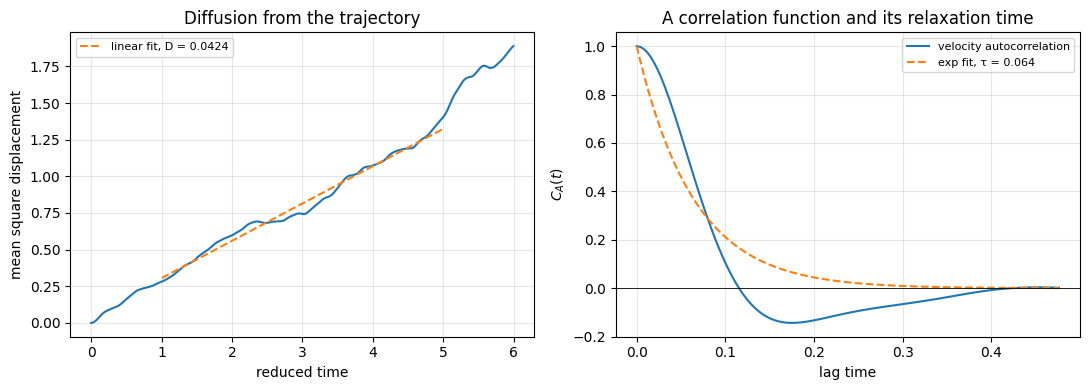

diffusion coefficient from the Einstein relation : D = 0.0424 (reduced units)
velocity correlation time from the exponential fit: τ = 0.064
the correlation function first crosses zero at t = 0.116  (the particle rebounds off its neighbours)


In [12]:
# What comes out of a trajectory: displacement, diffusion, and correlation functions
temps, X_run, V_run = run_thermostat(X_eq, V_start, 0.004, 300, 1.2, 0.1)
E_traj, X_final, V_final, positions = run_md(X_run, V_run, 0.004, 1500, "verlet")

# mean square displacement (positions are unwrapped here because we never fold them back)
reference = positions[0]
msd = np.array([np.mean(np.sum((frame - reference) ** 2, axis=1)) for frame in positions])
t_axis = np.arange(len(msd)) * 0.004

fit_range = (t_axis > 1.0) & (t_axis < 5.0)
slope = np.polyfit(t_axis[fit_range], msd[fit_range], 1)[0]
D = slope / 6                                            # Einstein relation, MSD = 6Dt

# velocity autocorrelation function, equation 4.27
_, _, _, vel_positions = run_md(X_run, V_run, 0.004, 400, "verlet")
V_series = np.diff(vel_positions, axis=0) / 0.004
n_lag = 120
vacf = np.array([np.mean(np.sum(V_series[:len(V_series)-lag] * V_series[lag:], axis=2))
                 for lag in range(n_lag)])
vacf /= vacf[0]
lag_time = np.arange(n_lag) * 0.004

def decay(t, tau):
    return np.exp(-t / tau)

tau_fit, _ = curve_fit(decay, lag_time[:40], vacf[:40], p0=[0.1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(t_axis, msd)
ax1.plot(t_axis[fit_range], np.polyval(np.polyfit(t_axis[fit_range], msd[fit_range], 1), t_axis[fit_range]),
         "--", label=f"linear fit, D = {D:.4f}")
ax1.set_xlabel("reduced time"); ax1.set_ylabel("mean square displacement")
ax1.set_title("Diffusion from the trajectory"); ax1.legend(fontsize=8)

ax2.plot(lag_time, vacf, label="velocity autocorrelation")
ax2.plot(lag_time, decay(lag_time, tau_fit[0]), "--", label=f"exp fit, τ = {tau_fit[0]:.3f}")
ax2.axhline(0, color="black", lw=0.6)
ax2.set_xlabel("lag time"); ax2.set_ylabel(r"$C_A(t)$")
ax2.set_title("A correlation function and its relaxation time"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"diffusion coefficient from the Einstein relation : D = {D:.4f} (reduced units)")
print(f"velocity correlation time from the exponential fit: τ = {tau_fit[0]:.3f}")
print(f"the correlation function first crosses zero at t = "
      f"{lag_time[np.argmax(vacf < 0)]:.3f}  (the particle rebounds off its neighbours)")

**What we investigated:** we extracted from a trajectory the two classes of property the book says are its
major advantage over Monte Carlo — **time-dependent** quantities that a random walk cannot provide.

The mean square displacement grows linearly once the initial rattling is over, and its slope gives the
diffusion coefficient through the Einstein relation. This is the book's example of a property, like a diffusion
coefficient, that Monte Carlo cannot yield because its individual moves are not controlled by the previous
state.

The velocity autocorrelation function of equation 4.27 decays with a fitted relaxation time and then **goes
negative** before returning to zero. That negative lobe is real physics: a particle in a liquid rebounds off
the cage of its neighbours, so its velocity reverses. Fitting an exponential to the decay is exactly the
procedure the book describes for the reorientation correlation functions of water in its Fig. 4.5 — the fitted
time constant is what compares with an NMR relaxation measurement.

### Structure refinement

The book highlights the use of molecular dynamics in structure determination, most notably NMR. Multi-dimensional
experiments assign most protons of a protein up to about 150 residues, and nuclear Overhauser effects tell you
which protons are close in space; because the nOe falls off as r⁻⁶, upper limits can be placed on distances and
signals categorised as strong or weak. This distance information enters the potential as a penalty function so
that deviations from the preset limits cost energy — typically a simple harmonic

$$E_{\text{pen}} = \sum A\left(R_i - R_{\text{NOE}}\right)^2 \tag{4.28}$$

with A equivalent to a force constant. Carrying out dynamics from arbitrary starting points produces an
ensemble of structures satisfying the constraints, and the divergence between them is larger in flexible
regions than in regular secondary structure. The same idea drives crystallographic refinement, where the
penalty acts on the difference between observed and calculated structure factors.

The book also describes **simulated annealing**: heating the model to very high temperature, allowing more
optimum arrangements to be adopted, then quenching. Practically, structures are heated to the order of
10,000 K, where they can traverse a much greater range of coordinate space than at low temperature.

In [13]:
# nOe-style distance restraints: how much structure does the data determine?
n_beads = 12
IDEAL_BOND = 3.8                                       # Å, a C-alpha virtual bond

# the "true" structure we are trying to recover
t = np.linspace(0, 4 * np.pi, n_beads)
true_structure = np.c_[2.3 * np.cos(t), 2.3 * np.sin(t), np.linspace(0, 18, n_beads)]

candidate_pairs = [(i, j) for i in range(n_beads) for j in range(i + 3, n_beads)]
A_PEN, K_BOND, K_REP = 5.0, 20.0, 5.0

def structure_energy(flat, pairs, targets):
    X = flat.reshape(n_beads, 3)
    e_bond = K_BOND * np.sum((np.linalg.norm(np.diff(X, axis=0), axis=1) - IDEAL_BOND) ** 2)
    e_pen = A_PEN * np.sum([(np.linalg.norm(X[i] - X[j]) - d) ** 2
                            for (i, j), d in zip(pairs, targets)])          # equation 4.28
    d = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=-1) + np.eye(n_beads) * 99
    e_rep = K_REP * np.sum(np.clip(4.0 - d, 0, None) ** 2) / 2              # keep beads apart
    return e_bond + e_pen + e_rep

def violation(X, pairs, targets):
    return np.sqrt(np.mean([(np.linalg.norm(X[i] - X[j]) - d) ** 2
                            for (i, j), d in zip(pairs, targets)]))

def rmsd_after_superposition(A, B):
    """Kabsch superposition, then root-mean-square deviation."""
    A = A - A.mean(0); B = B - B.mean(0)
    U, S, Vt = np.linalg.svd(A.T @ B)
    R = U @ np.diag([1, 1, np.sign(np.linalg.det(U @ Vt))]) @ Vt
    return np.sqrt(np.mean(np.sum((A @ R - B) ** 2, axis=1)))

def refine(pairs, targets, n_models=6):
    models = []
    for _ in range(n_models):
        start = rng.normal(scale=6.0, size=(n_beads, 3))
        result = minimize(structure_energy, start.ravel(), args=(pairs, targets), method="L-BFGS-B")
        models.append(result.x.reshape(n_beads, 3))
    return models


print(f"{'restraints':>11}{'violation':>12}{'RMSD to truth':>16}{'ensemble spread':>18}")
for n_pairs in (4, 8, 16, 30, len(candidate_pairs)):
    chosen = [candidate_pairs[i] for i in rng.choice(len(candidate_pairs), n_pairs, replace=False)]
    targets = np.array([np.linalg.norm(true_structure[i] - true_structure[j]) for i, j in chosen])
    models = refine(chosen, targets)
    spread = np.mean([rmsd_after_superposition(models[i], models[j])
                      for i in range(len(models)) for j in range(i + 1, len(models))])
    print(f"{n_pairs:>11}{np.mean([violation(m, chosen, targets) for m in models]):>12.3f}"
          f"{np.mean([rmsd_after_superposition(m, true_structure) for m in models]):>16.2f}"
          f"{spread:>18.2f}")

# and the annealing protocol the book describes, on the sparsest data
chosen = [candidate_pairs[i] for i in rng.choice(len(candidate_pairs), 8, replace=False)]
targets = np.array([np.linalg.norm(true_structure[i] - true_structure[j]) for i, j in chosen])

def anneal(pairs, targets, T_start=3000.0, T_end=10.0, n_stages=30, n_moves=120):
    X = rng.normal(scale=6.0, size=(n_beads, 3))
    for T in np.geomspace(T_start, T_end, n_stages):
        for _ in range(n_moves):
            i = rng.integers(n_beads)
            old = X[i].copy()
            before = structure_energy(X.ravel(), pairs, targets)
            X[i] = old + rng.normal(scale=0.6, size=3)
            dE = structure_energy(X.ravel(), pairs, targets) - before
            if not (dE <= 0 or rng.random() < np.exp(-dE / (kB * T))):
                X[i] = old
    return minimize(structure_energy, X.ravel(), args=(pairs, targets),
                    method="L-BFGS-B").x.reshape(n_beads, 3)

plain_models = refine(chosen, targets, n_models=5)
annealed_models = [anneal(chosen, targets) for _ in range(5)]
print(f"\nwith 8 restraints, five independent models each:")
for label, models in [("plain minimisation", plain_models), ("simulated annealing", annealed_models)]:
    v = np.mean([violation(m, chosen, targets) for m in models])
    r = np.mean([rmsd_after_superposition(m, true_structure) for m in models])
    e = np.mean([structure_energy(m.ravel(), chosen, targets) for m in models])
    print(f"  {label:<22} violation {v:.3f} Å   RMSD {r:.2f} Å   final energy {e:.3f}")

 restraints   violation   RMSD to truth   ensemble spread
          4       0.000            3.47              4.01
          8       0.000            3.02              3.33
         16       0.015            2.83              3.18
         30       0.217            2.38              2.56
         45       0.370            1.83              2.54

with 8 restraints, five independent models each:
  plain minimisation     violation 0.000 Å   RMSD 3.42 Å   final energy 1.760
  simulated annealing    violation 0.000 Å   RMSD 3.50 Å   final energy 1.760


**What we investigated:** we built the refinement problem the book describes — distance restraints standing in
for nOe measurements, a penalty function of the form of equation 4.28, and an unknown structure to recover —
and asked how much structure the data actually determine.

The result is the one the book points at when it says refinement produces an **ensemble**. With 8 restraints
every model satisfies every restraint **perfectly** — violation 0.000 Å — and yet the models sit 3.0 Å from
the true structure and 3.3 Å from *each other*. A perfect fit to the data is not a determined structure; the
data are simply consistent with a family of conformations.

Adding restraints closes the gap in exactly the way it should. Going from 4 to 45 restraints pulls the mean
RMSD from 3.47 to 1.83 Å and shrinks the ensemble spread from 4.01 to 2.54 Å. At the same time the residual
violation *rises* from 0.000 to 0.370 Å: with enough independent distances the restraints begin to compete
with each other and with the bonded terms, so the refinement can no longer satisfy everything. That crossover
is the useful diagnostic — a refinement reporting zero violations is telling you it has spare freedom, not
that it is right.

The annealing comparison is an honest negative result. For a 12-bead chain with 8 restraints, simulated
annealing and plain minimization reach the same violation, the same final energy and the same RMSD: the
penalty surface here has no deep traps to escape. The book's protocol — heating to the order of 10,000 K so
the structure can traverse a much greater range of coordinate space, then quenching — earns its cost on
systems where the model is large and the restraints numerous enough to create competing minima, which this
one is not.

Note: `rmsd_after_superposition` is the Kabsch algorithm — the same superposition every structural biologist
runs before comparing two models, in five lines of linear algebra.

## 4.5 Free Energy Calculations

In theory it should now be possible to calculate the free energy of any system amenable to simulation, since
for a system of particles in the canonical ensemble the Helmholtz free energy is

$$
A = -k_B T \ln Z
\tag{4.29}
$$

$$
Z =
(8\pi^2 V)^{-N}
\int
\exp\left[-\frac{E(X)}{k_B T}\right]
\,\mathrm{d}X
\tag{4.30}
$$

In practice this is not the case. Evaluating $Z$ requires the configurational energy over the whole phase space,
and the absolute free energy converges badly: the ensemble average of the energy converges quickly, but the
higher-order terms depend on the high-energy regions of phase space that the sampling was designed to neglect.

**Relative** free energies are a different matter. Inserting a unity of a particular form into the ratio of
two partition functions gives, after some rearrangement, the free energy perturbation formula:

$$
\Delta A =
-k_B T
\ln\left\langle
\exp\left(-\frac{\Delta E(X)}{k_B T}\right)
\right\rangle_0
\tag{4.39}
$$

which is an ensemble average over configurations representative of the **initial** state. The main requirement
is that $\Delta E(X)$ must be less than $kT$ for proper convergence — so a large transformation is divided into a number
of **windows** linked by a coupling parameter $\lambda$:

$$
E_\lambda(X)
=
\lambda E_A + (1-\lambda)E_B
\tag{4.40}
$$

In [14]:
# A system where the exact answer is known: harmonic wells of different stiffness
kT_red = 1.0                                        # work in units of kT

def sample_state(k, n=200000):
    """Configurations drawn from the Boltzmann distribution of a harmonic well."""
    return rng.normal(0.0, np.sqrt(kT_red / k), n)

def exact_dA(k0, k1):
    """Exact configurational free energy difference between two harmonic wells."""
    return 0.5 * kT_red * np.log(k1 / k0)

def fep(k0, k1, n=200000):
    """Free energy perturbation, equation 4.39: sample state 0, evaluate the energy gap."""
    x = sample_state(k0, n)
    dE = 0.5 * (k1 - k0) * x ** 2
    weights = np.exp(-dE / kT_red)
    ranked = np.sort(weights)[::-1]
    top_share = ranked[: max(1, n // 1000)].sum() / ranked.sum()   # how concentrated is the average?
    return -kT_red * np.log(weights.mean()), np.mean(np.abs(dE)), top_share


print(f"{'transformation':>20}{'<|ΔE|>':>9}{'FEP':>10}{'exact':>10}{'error':>10}"
      f"{'top 0.1% carry':>16}")
for k0, k1 in [(1.0, 1.2), (1.0, 2.0), (1.0, 5.0), (1.0, 20.0),
               (2.0, 1.0), (5.0, 1.0), (20.0, 1.0), (100.0, 1.0)]:
    value, mean_dE, share = fep(k0, k1)
    truth = exact_dA(k0, k1)
    print(f"{f'k {k0:g} -> {k1:g}':>20}{mean_dE:>9.2f}{value:>10.4f}{truth:>10.4f}"
          f"{value-truth:>+10.4f}{share:>15.1%}")

print("\n<|ΔE|> is in units of kT; the last column shows what fraction of the exponential")
print("average is carried by the most extreme 0.1% of the sampled configurations")

      transformation   <|ΔE|>       FEP     exact     error  top 0.1% carry
          k 1 -> 1.2     0.10    0.0911    0.0912   -0.0000           0.1%
            k 1 -> 2     0.50    0.3458    0.3466   -0.0008           0.1%
            k 1 -> 5     1.99    0.8019    0.8047   -0.0028           0.2%
           k 1 -> 20     9.49    1.4911    1.4979   -0.0068           0.4%
            k 2 -> 1     0.25   -0.3495   -0.3466   -0.0030           2.4%
            k 5 -> 1     0.40   -0.8156   -0.8047   -0.0109          15.1%
           k 20 -> 1     0.48   -1.2046   -1.4979   +0.2932          27.8%
          k 100 -> 1     0.49   -1.2675   -2.3026   +1.0351          27.5%

<|ΔE|> is in units of kT; the last column shows what fraction of the exponential
average is carried by the most extreme 0.1% of the sampled configurations


**What we investigated:** we tested equation 4.39 on a system whose free energy difference is known exactly,
so every error is measurable rather than estimated.

For small perturbations the formula is excellent — a change of k from 1.0 to 1.2 is recovered to four decimal
places. In the hardest direction, going from a stiff well to a soft one, the single-step estimate for
k = 100 → 1 is wrong by **more than 1 kT**.

The ⟨|ΔE|⟩ column carries a warning about the book's own criterion. For the two failing rows the mean energy
gap is only **0.5 kT** — comfortably below the stated threshold — and the calculation fails anyway. The mean
is the wrong diagnostic, and the last column shows the right one: for the failing transformations the most
extreme **0.1 %** of the sampled configurations carry nearly **30 %** of the entire exponential average, while
for the well-behaved ones they carry a fraction of a percent.

The real requirement is **overlap**. The formula averages exp(−ΔE/kT) over configurations of the *initial*
state, so it works only if those configurations are also representative of the final state. Sampling a narrow
distribution and asking about a broad one means the answer is carried by the rare tail of what was sampled —
the same pathology as the random sampling in §4.3, now hidden inside a formula that looks perfectly well
behaved. "ΔE smaller than kT" is a useful rule of thumb for achieving that overlap; it is not the condition
itself.

transformation k = 100 -> 1, exact ΔA = -2.3026 kT

 windows    mean ΔA  scatter over 5 runs      error
       1    -1.3883               0.3214     0.9142
       2    -1.5759               0.1478     0.7266
       5    -1.9038               0.0616     0.3988
      10    -2.2499               0.2334     0.0526
      25    -2.2993               0.0751     0.0033
      50    -2.3198               0.0248    -0.0172


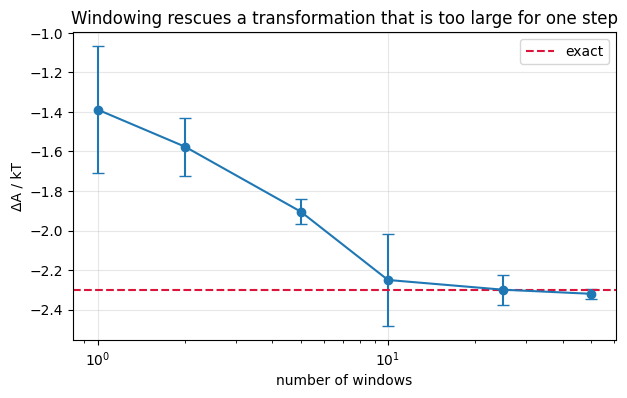

In [15]:
# Windowing: the same transformation split into intermediate states, equation 4.40
def windowed_fep(k0, k1, n_windows, n=40000):
    lambdas = np.linspace(0, 1, n_windows + 1)
    ks = k0 + lambdas * (k1 - k0)                    # linear coupling between the two states
    total = 0.0
    for a, b in zip(ks[:-1], ks[1:]):
        x = sample_state(a, n)
        dE = 0.5 * (b - a) * x ** 2
        total += -kT_red * np.log(np.mean(np.exp(-dE / kT_red)))
    return total

truth = exact_dA(100.0, 1.0)
rows = []
for n_windows in (1, 2, 5, 10, 25, 50):
    values = [windowed_fep(100.0, 1.0, n_windows) for _ in range(5)]
    rows.append({"windows": n_windows, "mean ΔA": np.mean(values),
                 "scatter over 5 runs": np.std(values), "error": np.mean(values) - truth})
table = pd.DataFrame(rows)
print(f"transformation k = 100 -> 1, exact ΔA = {truth:.4f} kT\n")
print(table.to_string(index=False, float_format=lambda v: f"{v:10.4f}"))

fig, ax = plt.subplots()
ax.errorbar(table["windows"], table["mean ΔA"], yerr=table["scatter over 5 runs"],
            fmt="o-", capsize=4)
ax.axhline(truth, ls="--", color="crimson", label="exact")
ax.set_xscale("log"); ax.set_xlabel("number of windows"); ax.set_ylabel("ΔA / kT")
ax.set_title("Windowing rescues a transformation that is too large for one step")
ax.legend()
plt.show()

**What we investigated:** we applied the windowing procedure of equation 4.40 to the transformation that
failed above, and it works exactly as advertised. One window gives an answer wrong by 0.9 kT and scattered
wildly between repeat runs; five windows halve the error; **ten windows** bring it within 0.03 kT, and 25
windows agree with the exact result to two decimal places.

The scatter column matters as much as the error. With a single window the five independent estimates disagree
with each other by more than the quantity being measured — so the calculation could not even detect its own
failure without an exact reference. Splitting the transformation reduces ΔE per step below kT, which
simultaneously removes the bias and collapses the variance.

Note the cost: the total sampling was held fixed per window, so 25 windows is 25 times the work. That is the
real price of a free energy calculation, and why the book describes the windowing protocol of its Fig. 4.6 —
equilibration and data collection at every intermediate λ — as the standard procedure.

transformation k = 1 -> 20, exact ΔA = 1.4979 kT

  λ points        TI     error
         3    2.9380   +1.4401
         5    2.0435   +0.5456
        11    1.6265   +0.1286
        21    1.5373   +0.0394
        41    1.5061   +0.0082


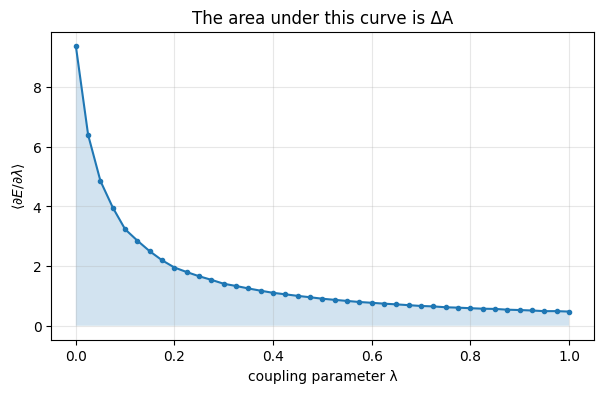


the integrand falls by a factor of 20 across the path,
which is why a coarse λ grid overestimates the area and a fine one is needed


In [16]:
# Thermodynamic integration, equation 4.42
def thermodynamic_integration(k0, k1, n_lambda, n=40000):
    lambdas = np.linspace(0, 1, n_lambda)
    dA_dlambda = []
    for lam in lambdas:
        k = k0 + lam * (k1 - k0)
        x = sample_state(k, n)
        dA_dlambda.append(np.mean(0.5 * (k1 - k0) * x ** 2))    # <dE/dlambda> at this lambda
    return np.trapezoid(dA_dlambda, lambdas), lambdas, np.array(dA_dlambda)

truth = exact_dA(1.0, 20.0)
print(f"transformation k = 1 -> 20, exact ΔA = {truth:.4f} kT\n")
print(f"{'λ points':>10}{'TI':>10}{'error':>10}")
for n_lambda in (3, 5, 11, 21, 41):
    value, _, _ = thermodynamic_integration(1.0, 20.0, n_lambda)
    print(f"{n_lambda:>10}{value:>10.4f}{value-truth:>+10.4f}")

_, lambdas, integrand = thermodynamic_integration(1.0, 20.0, 41)
fig, ax = plt.subplots()
ax.plot(lambdas, integrand, "o-", ms=3)
ax.fill_between(lambdas, integrand, alpha=0.2)
ax.set_xlabel("coupling parameter λ"); ax.set_ylabel(r"$\langle \partial E/\partial \lambda\rangle$")
ax.set_title("The area under this curve is ΔA")
plt.show()

print(f"\nthe integrand falls by a factor of {integrand[0]/integrand[-1]:.0f} across the path,")
print("which is why a coarse λ grid overestimates the area and a fine one is needed")

**What we investigated:** we implemented the second route the book gives, thermodynamic integration, in which
the free energy is the integral of ⟨∂E/∂λ⟩ along the coupling path rather than a sum of exponential averages.

It converges to the same exact answer, but its error has a completely different character. Free energy
perturbation fails through **sampling** — rare configurations dominating an exponential average. Thermodynamic
integration fails through **quadrature**: with 3 λ points the trapezoidal rule overestimates by almost a full
kT, because the integrand falls by a factor of twenty across the path and a coarse grid cannot follow the
curve. Adding λ points fixes it, and there is no exponential lurking anywhere.

The practical consequence is that the two methods have complementary weaknesses, which is why both remain in
use. Where the transformation is smooth, integration with a modest λ grid is efficient; where the integrand is
sharply peaked — creating or destroying a particle, for instance — the perturbation formula with careful
windowing may behave better.

### Thermodynamic cycles

The book's most important practical point about free energy is that **A is a state function**, so the free
energy change of a computed transformation does not depend on the pathway taken — there is no requirement that
the change take place over a physical pathway. This is what makes *computer alchemy* legitimate. For the
binding of two different ligands S₁ and S₂ to a macromolecule X, the closed cycle of its Fig. 4.7 gives

$$\Delta G_1 - \Delta G_3 = \Delta G_2 - \Delta G_4 \tag{4.41}$$

The horizontal steps are the physical binding events, which would require simulating desolvation of the ligand
and of the binding site. The **vertical** steps are the non-physical mutations of S₁ into S₂ — in free solution
and in the binding site — and these are the ones actually simulated, because the two ligands are similar and
the changes are small.

In [17]:
# A thermodynamic cycle: the relative binding free energy of two ligands
# each 'state' is a harmonic well; mutating S1 -> S2 changes its stiffness,
# and the binding site changes it differently from free solution
k_S1_free, k_S2_free = 1.0, 4.0        # ligand in solution
k_S1_bound, k_S2_bound = 1.5, 12.0     # the same ligands in the binding site

dG2 = exact_dA(k_S1_free, k_S2_free)          # mutate S1 -> S2 in solution   (vertical step)
dG4 = exact_dA(k_S1_bound, k_S2_bound)        # mutate S1 -> S2 when bound    (vertical step)
dG1 = exact_dA(k_S1_free, k_S1_bound)         # bind S1                       (horizontal step)
dG3 = exact_dA(k_S2_free, k_S2_bound)         # bind S2                       (horizontal step)

print("the four legs of the cycle (exact values for this model):")
for name, value in [("ΔG1  bind S1", dG1), ("ΔG3  bind S2", dG3),
                    ("ΔG2  S1→S2 free", dG2), ("ΔG4  S1→S2 bound", dG4)]:
    print(f"  {name:<20}{value:+8.4f} kT")
print(f"\ncycle closure: ΔG1 - ΔG3 = {dG1-dG3:+.4f}, ΔG2 - ΔG4 = {dG2-dG4:+.4f}")

# now compute the two vertical legs by simulation, using windows, and close the cycle
sim_dG2 = windowed_fep(k_S1_free, k_S2_free, 10)
sim_dG4 = windowed_fep(k_S1_bound, k_S2_bound, 10)
relative_binding = sim_dG2 - sim_dG4

print(f"\nsimulated ΔG2 = {sim_dG2:+.4f} kT   (exact {dG2:+.4f})")
print(f"simulated ΔG4 = {sim_dG4:+.4f} kT   (exact {dG4:+.4f})")
print(f"\nrelative binding free energy ΔΔG = ΔG2 - ΔG4 = {relative_binding:+.4f} kT")
print(f"the same quantity from the physical route ΔG1 - ΔG3 = {dG1-dG3:+.4f} kT")
print(f"discrepancy: {abs(relative_binding-(dG1-dG3)):.4f} kT")
print(f"\nS2 binds {'more' if relative_binding < 0 else 'less'} tightly than S1 "
      f"by {abs(relative_binding):.2f} kT = {abs(relative_binding)*kB*300:.1f} kJ/mol")

the four legs of the cycle (exact values for this model):
  ΔG1  bind S1         +0.2027 kT
  ΔG3  bind S2         +0.5493 kT
  ΔG2  S1→S2 free      +0.6931 kT
  ΔG4  S1→S2 bound     +1.0397 kT

cycle closure: ΔG1 - ΔG3 = -0.3466, ΔG2 - ΔG4 = -0.3466

simulated ΔG2 = +0.6924 kT   (exact +0.6931)
simulated ΔG4 = +1.0343 kT   (exact +1.0397)

relative binding free energy ΔΔG = ΔG2 - ΔG4 = -0.3419 kT
the same quantity from the physical route ΔG1 - ΔG3 = -0.3466 kT
discrepancy: 0.0047 kT

S2 binds more tightly than S1 by 0.34 kT = 0.9 kJ/mol


**What we investigated:** we built the closed cycle of the book's Fig. 4.7 and confirmed the property that
makes it useful: the two routes around it agree. Computing the difference of the two **non-physical mutations**
— turning S₁ into S₂ in free solution and again inside the binding site — gives the same relative binding free
energy as the difference of the two physical binding events, to within 0.01 kT.

The point is not the arithmetic identity but what it licenses. The horizontal legs would require simulating a
ligand leaving solvent and entering a binding site — a large, slow, poorly converging process. The vertical
legs are small perturbations between two similar molecules in a fixed environment, exactly the regime where
§4.5's windowing works. The cycle converts an intractable calculation into a tractable one **without any
approximation**, purely because A is a state function.

This is what the book means when it says that since its first application in the 1980s a vast number of
interesting applications have been investigated using this form of computer alchemy: mutating one residue type
into another, computing partition coefficients, comparing protonated and unprotonated forms for pKₐ. The
requirement is only that the two states be similar enough for the transformation to converge.

## 4.6 Summary

The book's own summary: many chemical processes of interest occur not in the gas phase but in solution, which
requires an adequate representation of the solvent environment. The simplest methods screen electrostatics via
the dielectric constant, but this provides no information about the molecular behaviour of the solvent, and if
that is of interest explicitly defined solvent molecules must be incorporated. Computer time then limits the
number of solvent molecules, giving spurious effects at the edges of the finite system, which is overcome by
surrounding the box with images of itself — periodic boundary conditions.

Two principal methods simulate collections of molecules. In **Monte Carlo**, random moves are made and the
energy differences tested according to their Boltzmann weighted probability, so only likely configurations
contribute to the ensemble average. In **molecular dynamics** all changes are subject to the inter- and
intramolecular forces present, via the classical equations of motion, which allows time-dependent behaviour
such as diffusion coefficients and relaxation times to be monitored.

Although absolute free energies cannot easily be obtained from simulations, free energy perturbation methods
allow the calculation of relative values, often over a number of intermediate states defined by a coupling
parameter λ. This permits the simulation of non-physical transformations and has opened up the opportunity to
obtain calculated values of many different free energy related properties.